# Optimising the whole cavity: R/Q to a target

The usual workflow fixes each cell's frequency on its own — tune a mid cell to
`f`, tune an end cell to `f`, assemble, and the multi-cell cavity sits at `f`. This
example does something different: it optimises the **whole assembled cavity** so its
**R/Q meets a target**, while holding the accelerating frequency fixed.

The design variables come from the **end cells**, and three things keep the search
compact:

- The **`_e` suffix** means *both end cells, tied to one value*: `A_e` drives the
  left and right end-cell `A` together, so the cavity stays symmetric with a single
  variable.
- The objective **`['equal', 'monopole:R/Q [Ohm]', target]`** ranks designs by how
  close the whole-cavity R/Q is to the target.
- The frequency is held for every candidate by tuning **`L_e`** — both end-cell
  lengths, tied — to `f`.

The mid cell is tuned once up front and then held fixed.

In [1]:
import os
import tempfile
import warnings

import numpy as np
import matplotlib.pyplot as plt

from cavsim2d import Study, EllipticalCavity
from cavsim2d.utils.style import apply_style

warnings.filterwarnings('ignore')
apply_style()

F = 1300.0            # accelerating frequency [MHz]
NCELLS = 3            # cells in the cavity (one mid, two ends)
TARGET_RQ = 320.0     # whole-cavity R/Q target [Ohm]
MID0 = [42, 42, 12, 19, 35, 57.7, 103.3]      # A, B, a, b, Ri, L, Req [mm]

## 1. Tune the mid cell, then build the module

First bring a single mid cell to `f` by tuning its equator radius `Req`. The tuned
mid-cell dimensions become the fixed core of the module; the two end cells start as
copies of it and are what we will vary.

In [2]:
mid_study = Study(os.path.join(tempfile.mkdtemp(), 'midtune'))
mid_study.add_cavity([EllipticalCavity(1, MID0, MID0, MID0, beampipe='none', name='mid')], ['mid'])
mid_study.run_tune({'freqs': F, 'cell_type': {'mid-cell': 'Req'}, 'processes': 1,
                    'tol': 3e-3, 'rerun': True,
                    'eigenmode_config': {'processes': 1, 'boundary_conditions': 'mm'}})

p = mid_study.cavities_list[0].tuned.parameters
MID = [p['A_m'], p['B_m'], p['a_m'], p['b_m'], p['Ri_m'], p['L_m'], p['Req_m']]
print('tuned mid cell (Req %.3f -> %.3f mm):' % (MID0[6], MID[6]), [round(x, 3) for x in MID])

tuned mid cell (Req 103.300 -> 103.365 mm): [42.0, 42.0, 12.0, 19.0, 35.0, 57.7, 103.365]


## 2. Search the end-cell shape for a target R/Q

`bounds` are the end-cell shape variables, each with the **`_e`** suffix so the two
ends stay tied. `mid-cell` supplies the fixed mid-cell dimensions. The objective is
`['equal', 'monopole:R/Q [Ohm]', TARGET_RQ]` — minimise the distance of the
whole-cavity R/Q from the target — and `tune_config` uses **`L_e`** to hold the
frequency at `F` for every candidate.

  0%|          | 0/2 [00:00<?, ?it/s]

 50%|█████     | 1/2 [02:08<02:08, 128.39s/it]

100%|██████████| 2/2 [05:17<00:00, 163.88s/it]

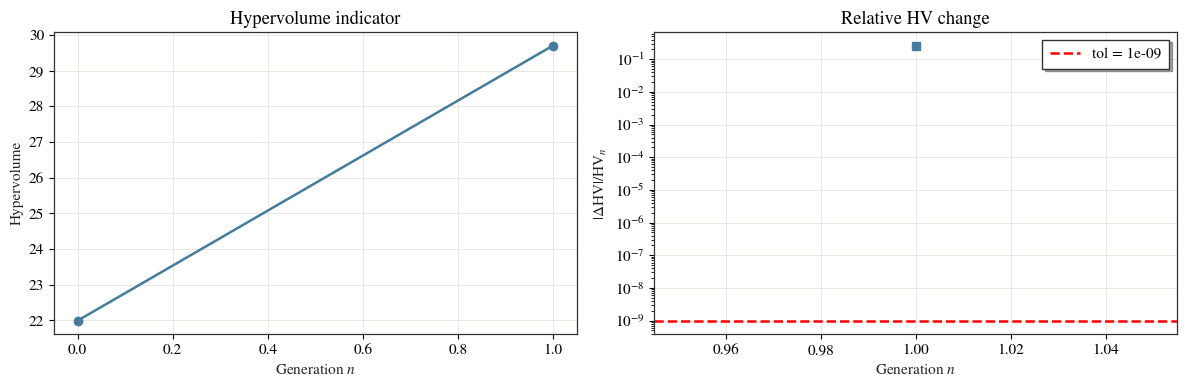

evaluated 12 candidates


In [3]:
study = Study(os.path.join(tempfile.mkdtemp(), 'rq_opt'))
study.add_cavity([EllipticalCavity(NCELLS, MID, MID, MID, beampipe='both', name='module')], ['module'])

config = {
    'initial_points': 6, 'no_of_generation': 2, 'method': {'LHS': {'seed': 5}},
    'mid-cell': MID,                                    # mid cell held fixed
    'bounds': {                                         # end-cell shape, both ends tied
        'A_e': [40, 46], 'B_e': [40, 46], 'a_e': [10, 14], 'b_e': [17, 21],
    },
    'objectives': [['equal', 'monopole:R/Q [Ohm]', TARGET_RQ]],
    'tune_config': {
        'freqs': F,
        'cell_type': {'end-cell': 'L_e'},              # tie & tune both end lengths to F
        'processes': 1,
        'eigenmode_config': {'n_cells': NCELLS, 'processes': 1, 'boundary_conditions': 'mm'},
    },
    'weights': [1],
    'mutation_factor': 3, 'crossover_factor': 3, 'elites_for_crossover': 2, 'chaos_factor': 2,
}
study.run_optimisation(config)
opt = study.optimisation
print('evaluated', len(opt.history), 'candidates')

## 3. Frequency held, R/Q driven to the target

Every candidate was tuned back to `F` by `L_e`, so the whole cavity stays on
frequency while its R/Q moves. Ranked by closeness to the target, the best design
sits right on it.

100%|██████████| 2/2 [05:17<00:00, 158.85s/it]

candidate frequencies [MHz]: [1300.0]


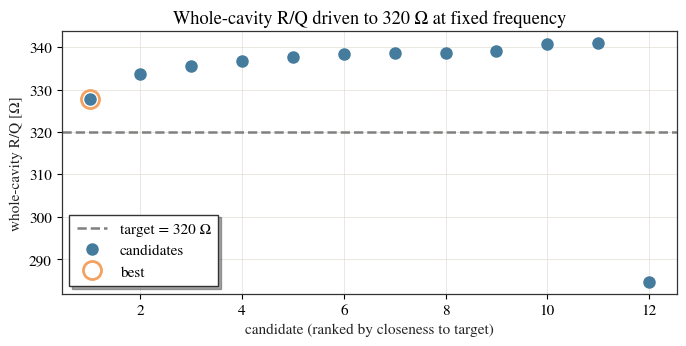

In [4]:
h = opt.history.copy()
h['|R/Q - target|'] = (h['monopole:R/Q [Ohm]'] - TARGET_RQ).abs()
h = h.sort_values('|R/Q - target|').reset_index(drop=True)

print('candidate frequencies [MHz]:', sorted(h['freq [MHz]'].round(3).unique()))

fig, ax = plt.subplots(figsize=(7, 3.6))
ax.axhline(TARGET_RQ, ls='--', color='0.5', label='target = %g Ω' % TARGET_RQ)
ax.plot(range(1, len(h) + 1), h['monopole:R/Q [Ohm]'], 'o', ms=8, label='candidates')
ax.plot(1, h['monopole:R/Q [Ohm]'].iloc[0], 'o', ms=13, mfc='none', mec='C3', mew=2, label='best')
ax.set_xlabel('candidate (ranked by closeness to target)')
ax.set_ylabel('whole-cavity R/Q [Ω]')
ax.set_title('Whole-cavity R/Q driven to %g Ω at fixed frequency' % TARGET_RQ)
ax.legend(); plt.tight_layout(); plt.show()

The best design — the tied end-cell shape and the tuned end-cell length `L_e`
that holds the frequency:

In [5]:
cols = ['A_e', 'B_e', 'a_e', 'b_e', 'L_e', 'freq [MHz]', 'monopole:R/Q [Ohm]', '|R/Q - target|']
h[cols].round(3).head(6)

,A_e,B_e,a_e,b_e,L_e,freq [MHz],monopole:R/Q [Ohm],|R/Q - target|
0,44.500,44.500,11.000,18.000,65.480,1300.0,327.760,7.760
1,43.645,43.277,10.989,19.506,63.134,1300.0,333.732,13.732
2,43.500,43.500,11.000,19.333,62.350,1300.0,335.461,15.461
3,42.808,41.682,10.728,19.905,61.560,1300.0,336.674,16.674
4,41.500,41.500,13.000,20.000,61.482,1300.0,337.649,17.649
5,42.500,41.500,10.333,20.000,59.919,1300.0,338.510,18.510


**Reading it.** The `_e` variables kept the two end cells symmetric throughout;
`L_e` held every candidate at `F`; and the `equal` objective steered the population
toward the target whole-cavity R/Q. Swapping the objective (`'min'`/`'max'`) or adding
a second one turns this into the multi-objective search shown in the other examples.